<a href="https://colab.research.google.com/github/ClassNeuralNetwork/classification-liver-patient/blob/main/classification_liver_patient.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import shap
import joblib

In [ ]:
# Leitura do Dataset
df = pd.read_csv('Indian Liver Patient Dataset.csv')
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               583 non-null    int64  
 1   gender            583 non-null    object 
 2   tot_bilirubin     583 non-null    float64
 3   direct_bilirubin  583 non-null    float64
 4   tot_proteins      583 non-null    int64  
 5   albumin           583 non-null    int64  
 6   ag_ratio          583 non-null    int64  
 7   sgpt              583 non-null    float64
 8   sgot              583 non-null    float64
 9   alkphos           579 non-null    float64
 10  is_patient        583 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 50.2+ KB


,age,gender,tot_bilirubin,direct_bilirubin,tot_proteins,albumin,ag_ratio,sgpt,sgot,alkphos,is_patient
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [ ]:
# Tratamento de dados nulos
df['alkphos'] = df['alkphos'].fillna(df['alkphos'].median())

# Mapeia 'gender': Male = 1, Female = 0
df['gender'] = df['gender'].astype(str).str.strip().map({'Male': 1, 'Female': 0})

# Ajusta a variável alvo 'is_patient'
df['is_patient'] = df['is_patient'].map({1: 1, 2: 0})

In [ ]:
# Separação dos Dados
x = df.drop(columns=['is_patient'])
y = df['is_patient']

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2, random_state=42, stratify=y
)

# Padronização
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
# Construção do modelo
model = Sequential([
    Input(shape=(x_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compilação
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Treinamento
history = model.fit(
    x_train_scaled,
    y_train,
    epochs=100,
    batch_size=8,
    validation_split=0.15,
)

Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5732 - loss: 0.6670 - val_accuracy: 0.6571 - val_loss: 0.5931
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6970 - loss: 0.5799 - val_accuracy: 0.7143 - val_loss: 0.5512
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7146 - loss: 0.5496 - val_accuracy: 0.7429 - val_loss: 0.5302
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7197 - loss: 0.5345 - val_accuracy: 0.7286 - val_loss: 0.5210
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7146 - loss: 0.5255 - val_accuracy: 0.7286 - val_loss: 0.5151
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7146 - loss: 0.5181 - val_accuracy: 0.7429 - val_loss: 0.5146
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7273 - loss: 0.5147 - val_accuracy: 0.7429 - val_loss: 0.5151
Epoch 8/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7273 - loss: 0.5106 - val_accuracy: 0.7429 - v

# Avaliação Modelo de 16 neurônios


Acurácia no conjunto de Teste:0.7692

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

Relatório de Classificação:
               precision    recall  f1-score   support

    Saudável       0.68      0.38      0.49        34
      Doente       0.79      0.93      0.85        83

    accuracy                           0.77       117
   macro avg       0.73      0.66      0.67       117
weighted avg       0.76      0.77      0.75       117



<Figure size 500x400 with 0 Axes>

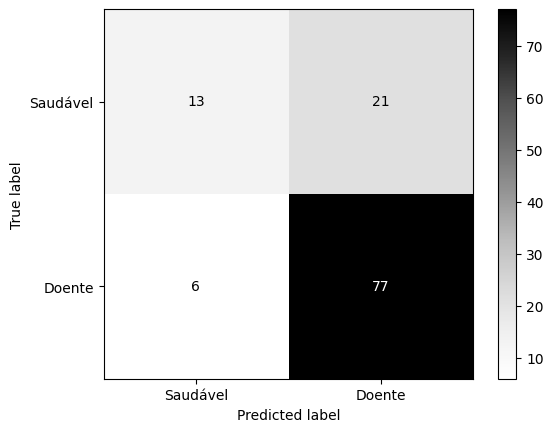

In [ ]:
# Avaliação Modelo de 16 neurônios
loss, accuracy = model.evaluate(x_test_scaled, y_test, verbose=0)
print(f'\nAcurácia no conjunto de Teste:{accuracy:.4f}\n')

# Conversão de probabilidades em classes binárias (0 ou 1)
y_pred_probs = model.predict(x_test_scaled)
y_pred = (y_pred_probs > 0.5).astype(int)

class_names = ['Saudável','Doente']

matriz_confusao = confusion_matrix(y_test, y_pred)
plt.figure(figsize=[5, 4])
display_matriz = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao, display_labels=class_names)
display_matriz.plot(cmap='Greys')

print('\nRelatório de Classificação:\n', classification_report(y_test, y_pred, target_names=class_names))

# Avaliação Modelo de 32 neurônios


Acurácia no conjunto de Teste:0.7521

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step

Relatório de Classificação:
               precision    recall  f1-score   support

    Saudável       0.61      0.41      0.49        34
      Doente       0.79      0.89      0.84        83

    accuracy                           0.75       117
   macro avg       0.70      0.65      0.66       117
weighted avg       0.74      0.75      0.74       117



<Figure size 500x400 with 0 Axes>

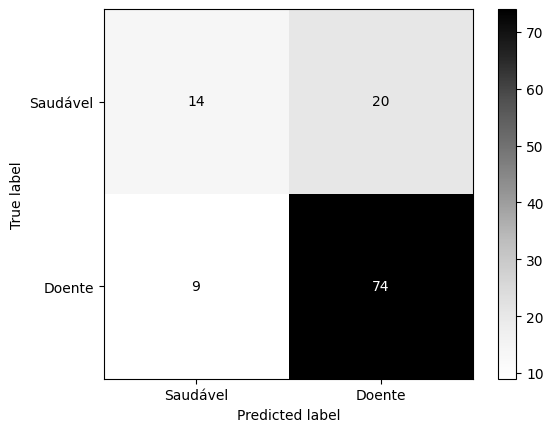

In [ ]:
# Avaliação Modelo de 32 neurônios
loss, accuracy = model.evaluate(x_test_scaled, y_test, verbose=0)
print(f'\nAcurácia no conjunto de Teste:{accuracy:.4f}\n')

# Conversão de probabilidades em classes binárias (0 ou 1)
y_pred_probs = model.predict(x_test_scaled)
y_pred = (y_pred_probs > 0.5).astype(int)

class_names = ['Saudável','Doente']

matriz_confusao = confusion_matrix(y_test, y_pred)
plt.figure(figsize=[5, 4])
display_matriz = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao, display_labels=class_names)
display_matriz.plot(cmap='Greys')

print('\nRelatório de Classificação:\n', classification_report(y_test, y_pred, target_names=class_names))

# Avaliação Modelo de 2 camadas 16-8 neurônios


Acurácia no conjunto de Teste:0.7436

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

Relatório de Classificação:
               precision    recall  f1-score   support

    Saudável       0.58      0.44      0.50        34
      Doente       0.79      0.87      0.83        83

    accuracy                           0.74       117
   macro avg       0.68      0.65      0.66       117
weighted avg       0.73      0.74      0.73       117



<Figure size 500x400 with 0 Axes>

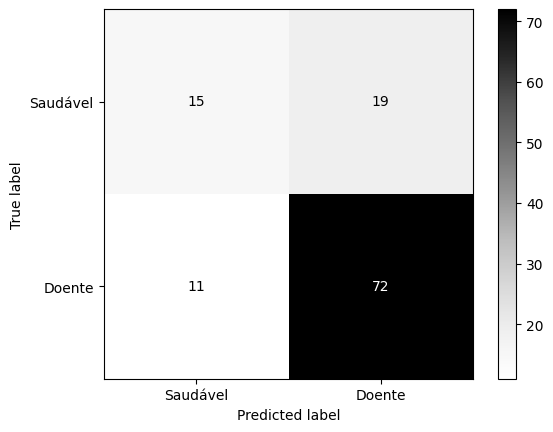

In [ ]:
# Avaliação Modelo de 2 camadas 16-8 neurônios
loss, accuracy = model.evaluate(x_test_scaled, y_test, verbose=0)
print(f'\nAcurácia no conjunto de Teste:{accuracy:.4f}\n')

# Conversão de probabilidades em classes binárias (0 ou 1)
y_pred_probs = model.predict(x_test_scaled)
y_pred = (y_pred_probs > 0.5).astype(int)

class_names = ['Saudável','Doente']

matriz_confusao = confusion_matrix(y_test, y_pred)
plt.figure(figsize=[5, 4])
display_matriz = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao, display_labels=class_names)
display_matriz.plot(cmap='Greys')

print('\nRelatório de Classificação:\n', classification_report(y_test, y_pred, target_names=class_names))

# Avaliação Modelo de 2 camadas 32-16 neurônios


Acurácia no conjunto de Teste:0.7778

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

Relatório de Classificação:
               precision    recall  f1-score   support

    Saudável       0.62      0.59      0.61        34
      Doente       0.84      0.86      0.85        83

    accuracy                           0.78       117
   macro avg       0.73      0.72      0.73       117
weighted avg       0.77      0.78      0.78       117



<Figure size 500x400 with 0 Axes>

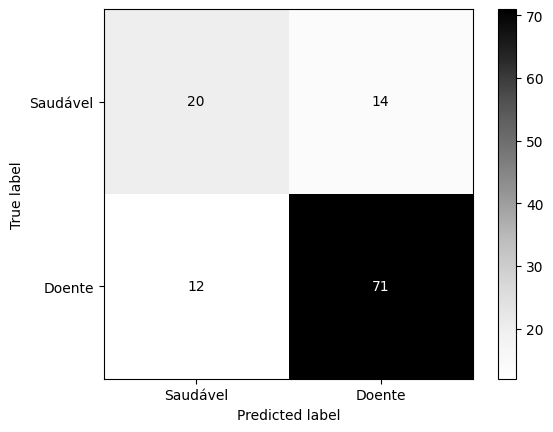

In [ ]:
# Avaliação Modelo de 2 camadas 32-16 neurônios
loss, accuracy = model.evaluate(x_test_scaled, y_test, verbose=0)
print(f'\nAcurácia no conjunto de Teste:{accuracy:.4f}\n')

# Conversão de probabilidades em classes binárias (0 ou 1)
y_pred_probs = model.predict(x_test_scaled)
y_pred = (y_pred_probs > 0.5).astype(int)

class_names = ['Saudável','Doente']

matriz_confusao = confusion_matrix(y_test, y_pred)
plt.figure(figsize=[5, 4])
display_matriz = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao, display_labels=class_names)
display_matriz.plot(cmap='Greys')

print('\nRelatório de Classificação:\n', classification_report(y_test, y_pred, target_names=class_names))

In [ ]:
# 1. Salvar o modelo Keras
model.save('modelo_pacientes_figado.keras')

# 2. Salvar o padronizador de dados (Scaler)
joblib.dump(scaler, 'scaler_figado.pkl')

['scaler_figado.pkl']

In [ ]:
# Interpretar modelo com SHAP
explainer = shap.KernelExplainer(model.predict, x_test_scaled[:50])
shap_values = explainer.shap_values(x_test_scaled)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


  0%|          | 0/117 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1597/1597 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1597/1597 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1597/1597 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1597/1597 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1597/1597 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1597/1597 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1597/1597 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1597/1597 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1597/1597 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1597/1597 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1597/1597 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1597/1597 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

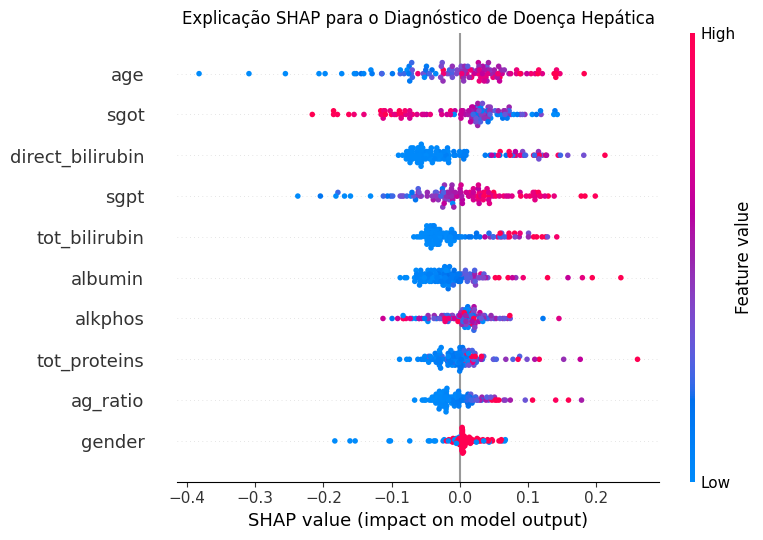

In [ ]:
feature_names = list(x.columns)

if len(shap_values.shape) == 3:
    shap_vals_plot = shap_values[:, :, 0]
else:
    shap_vals_plot = shap_values

plt.figure(figsize=(8, 4))
plt.title('Explicação SHAP para o Diagnóstico de Doença Hepática')

shap.summary_plot(
    shap_vals_plot,
    x_test_scaled,
    feature_names=feature_names,
    show=False
)

plt.tight_layout()
plt.show()